# MNIST-Planted-Cov: backbone pretraining and run analysis

Two jobs in one notebook, both for the planted-covariance design in
`datasets/MNIST_add_cov_dataset_planted.py` (`+data=mnist_planted_cov`):

```
input      five MNIST digits stacked as channels           [5, 28, 28]
concepts   A = 1[d1>=5]  B = 1[d2>=5]  D1 = 1[d3>=5]  D2 = 1[d4>=5]     supervised
hidden     X = 1[d5>=5]                                                never supervised
target     y = 4A + 2B + X                                             8 classes
planted    P(X=1 | A,B) = 0.5 + kappa/2 (A + B - 1)   ->  corr(A,X) = corr(B,X) = kappa/2
           corr(D1,X) = corr(D2,X) = 0 by construction
```

**Part 1** trains the per-channel digit encoder on *exactly* this input: 5 channels, the
noise on channel 5 that the SCBM run will see, the same split seed. That removes the two
mismatches of the carry backbone (4 channels, clean digits). The result is a state dict for
`model.pretrained_encoder_path`.

**Part 2** reads a finished run's dumps (`<run>/test/*.pt` + `model_best.pth`) and answers,
in order: did the residual pick up X, and does the concept-residual correlation point at
A and B rather than D1 and D2? Everything in Part 2 is self-contained: X is recovered from
the dumps as `y_true - 4A - 2B`, so no dataset rebuild is needed for the analysis.

Guardrail: probes and correlations say what is *recoverable* from the residual and which
concepts it *co-varies* with. They do not say the residual "is" X.

## 0. Setup

In [1]:
import os, sys, json, socket, time
from pathlib import Path

REPO_DEFAULT = Path("/Users/stephenmarcou/Documents/ETH Zurich/Cambridge/Code/SCBM_implementation")

def find_repo_root(start=None):
    marker = Path("datasets") / "MNIST_add_cov_dataset_planted.py"
    for c in [Path(start or Path.cwd()).resolve(), *Path(start or Path.cwd()).resolve().parents]:
        if (c / marker).is_file():
            return c
    return REPO_DEFAULT

REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from omegaconf import OmegaConf

from datasets.MNIST_add_cov_dataset_planted import (
    get_MNIST_add_cov_datasets, summarize_dataset, CONCEPT_NAMES,
)
from models.models import PerChannelMNISTEncoder
from utils.utils import reset_random_seeds

ON_CLUSTER = "biomed" in socket.gethostname()
DATA_PATH = "/cluster/home/smarcou/work/Data/" if ON_CLUSTER else "datasets/"
EXPERIMENTS = Path("/cluster/home/smarcou/work/experiments_scbm") if ON_CLUSTER else REPO_ROOT / "experiments"
BACKBONE_ROOT = Path("/cluster/home/smarcou/work/backbones") if ON_CLUSTER else REPO_ROOT / "experiments" / "backbones"

device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"repo {REPO_ROOT}\ndata {DATA_PATH}\ndevice {device}")

/Users/stephenmarcou/Documents/ETH Zurich/Cambridge/Code/SCBM_implementation/scbm_implementation/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


repo /Users/stephenmarcou/Documents/ETH Zurich/Cambridge/Code/SCBM_implementation
data datasets/
device mps


### The run these settings describe

Everything below is keyed on this one block. The backbone is trained on the same split the
SCBM run trains on (`data_seed`), with the same corruption on the same channel, so the
encoder never sees an input distribution the run will not show it.

In [2]:
EXPERIMENT   = "planted_parents"   # planted_parents | planted_swap | planted_diff
KAPPA        = 0.6                 # corr(parent, X) = KAPPA / 2
CORR_X       = 0.0                 # gaussian corruption on channel 5 (X's digit) only; 0.0 -> clean
CORR_C       = 0.0                 # corruption on channels 1-4 (keep 0 for the first round)
DATA_SEED    = 0                   # split seed; pass the same as data.data_seed to train.py
NUM_CHANNELS = 5

# Backbone training budget. The capacity notebook used the model config's 300 epochs /
# patience 75; a digit reader converges far sooner, so these are capped here.
BB_EPOCHS      = 60
BB_PATIENCE    = 10
BB_MIN_EPOCHS  = 20
BB_LR          = 1e-4
BB_BATCH       = 64

# True: train the backbone in Part 1 and save it. False: load BACKBONE_DIR/encoder.pt,
# freeze it, fit fresh linear digit heads on top (the saved file holds only the encoder),
# and run the test-accuracy cell against that. The save cell is skipped either way when
# False. Part 2 needs neither.
TRAIN_BACKBONE = False
HEAD_EPOCHS    = 3      # linear-probe budget for the fresh heads when TRAIN_BACKBONE=False
HEAD_LR        = 1e-3

BACKBONE_NAME = f"{EXPERIMENT}_k{KAPPA}_cx{CORR_X}_cc{CORR_C}_s{DATA_SEED}_perchannel".replace(".", "")
BACKBONE_DIR  = BACKBONE_ROOT / BACKBONE_NAME
print("backbone ->", BACKBONE_DIR / "encoder.pt")

backbone -> /Users/stephenmarcou/Documents/ETH Zurich/Cambridge/Code/SCBM_implementation/experiments/backbones/planted_parents_k06_cx00_cc00_s0_perchannel/encoder.pt


## 1. The dataset, built the way `train.py` builds it

In [3]:
config_data = OmegaConf.merge(
    OmegaConf.load("configs/data/data_defaults.yaml"),
    OmegaConf.load("configs/data/mnist_planted_cov.yaml"),
)
OmegaConf.set_struct(config_data, False)
config_data.data_path = DATA_PATH
config_data.experiment = EXPERIMENT
config_data.kappa = KAPPA
config_data.num_covariates = NUM_CHANNELS
config_data.corruption = "gaussian"
config_data.corruption_strength = CORR_X
config_data.concept_corruption_strength = CORR_C
config_data.data_seed = DATA_SEED

# utils/data.py passes data_seed when set, else the run seed. Same here.
split_seed = DATA_SEED if DATA_SEED is not None else 0
gen = reset_random_seeds(split_seed)
torch.use_deterministic_algorithms(False)   # conv backward has no deterministic CUDA kernel

trainset, valset, testset = get_MNIST_add_cov_datasets(config_data, seed=split_seed)
print(len(trainset), len(valset), len(testset))
summarize_dataset(trainset)

MNIST-Planted-Cov split fingerprints (data seed=0, experiment=planted_parents, kappa=0.6):
  train n=12000  sha256[:16]=c9ea31802cb6a67c
  val   n=2400   sha256[:16]=3457f6b917aa0c2b
  test  n=10000  sha256[:16]=a28e98414ecc5c60
  concepts exposed: ['A::digit1_ge_5', 'B::digit2_ge_5', 'D1::digit3_ge_5', 'D2::digit4_ge_5']
  planted parents : ['A', 'B']
  Matching fingerprints => identical train/val/test samples across machines.
12000 2400 10000
N=12000   experiment=planted_parents   kappa=0.6
  X depends on A and B, both positively
Channels: 5 (5 used, 0 padding)
Concepts exposed: ['A::digit1_ge_5', 'B::digit2_ge_5', 'D1::digit3_ge_5', 'D2::digit4_ge_5']
Concept means ['A', 'B', 'D1', 'D2']: [0.5 0.5 0.5 0.5]
P(X = 1) = 0.5044   (0.5 by construction, any kappa)
Task class counts: [2406  594 1463 1537 1505 1495  573 2427]

Marginal concept-X correlations (what the cross-block should recover):
  Corr(A, X) = +0.2985   expected +0.3000  <- parent
  Corr(B, X) = +0.3125   expected +0.3000 

### Design check

Empirical correlations on the split against the planted values. If A and B are not at
kappa/2 and D1, D2 not at zero, nothing downstream is interpretable.

In [4]:
def design_table(ds, kappa):
    obs = ds.observed_concepts; x = ds.hidden_concepts[:, 1]; y = ds.task_labels
    rows = []
    for j, name in enumerate(["A", "B", "D1", "D2"]):
        r = np.corrcoef(obs[:, j], x)[0, 1]
        rows.append((name, r))
    code_ = obs @ (2 ** np.arange(4)); hit = 0
    for k in np.unique(code_):
        m = code_ == k; hit += np.bincount(y[m].astype(int)).max()
    ceiling = hit / len(y)
    return rows, ceiling

rows, CEILING = design_table(trainset, KAPPA)
print(f"{'concept':>8} {'corr(c,X)':>10}   planted")
for name, r in rows:
    planted = KAPPA / 2 if name in ("A", "B") else 0.0
    if EXPERIMENT == "planted_swap": planted = KAPPA / 2 if name in ("D1", "D2") else 0.0
    if EXPERIMENT == "planted_diff": planted = {"A": KAPPA/2, "B": -KAPPA/2}.get(name, 0.0)
    print(f"{name:>8} {r:>+10.3f}   {planted:+.3f}")
print(f"\nconcept-only task ceiling (train): {CEILING:.4f}   designed {0.5 + KAPPA/4:.4f}")
print(f"residual headroom                : {1 - CEILING:.4f}")

 concept  corr(c,X)   planted
       A     +0.299   +0.300
       B     +0.313   +0.300
      D1     +0.019   +0.000
      D2     +0.013   +0.000

concept-only task ceiling (train): 0.6584   designed 0.6500
residual headroom                : 0.3416


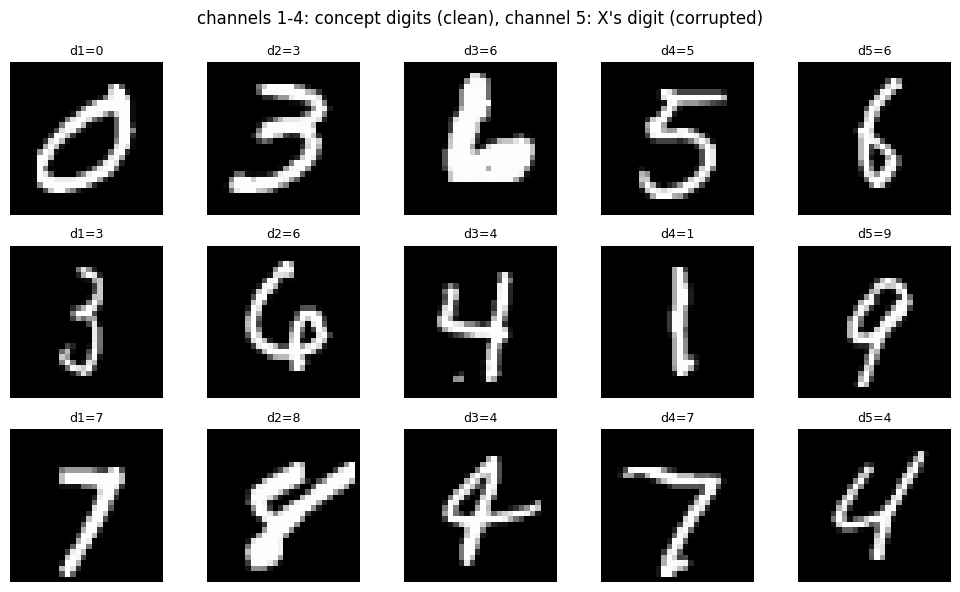

In [5]:
# A few samples: channels 1-4 clean, channel 5 noisy.
fig, axes = plt.subplots(3, NUM_CHANNELS, figsize=(2.0 * NUM_CHANNELS, 6))
for i in range(3):
    s = trainset[i]
    for c in range(NUM_CHANNELS):
        axes[i, c].imshow(s["features"][c], cmap="gray", vmin=0, vmax=1)
        axes[i, c].set_title(f"d{c+1}={int(s['digit_labels'][c])}", fontsize=9)
        axes[i, c].axis("off")
    axes[i, 0].set_ylabel(f"y={int(s['labels'])} X={int(s['X'])}")
plt.suptitle("channels 1-4: concept digits (clean), channel 5: X's digit (corrupted)")
plt.tight_layout(); plt.show()

## 2. Backbone: the per-channel digit encoder on this exact input

Same recipe as the capacity notebook's section 10b, with two changes that are the point of
doing it here: the encoder is the class from `models/models.py` (not a notebook copy, so the
state dict matches what `train.py` builds), and the input is the planted 5-channel stack
with channel 5 corrupted.

One 10-way digit head per channel, summed cross-entropy, Adam, early stopping on the mean
validation digit accuracy. The heads are thrown away; only `encoder.state_dict()` is saved.
The shared `digit_net` therefore has to read clean digits *and* the noisy fifth digit with
the same weights, which is what the SCBM run will demand of it.

In [6]:
class BackboneFrom(nn.Module):
    """Encoder + one 10-way head per channel. The heads exist only for pretraining."""
    def __init__(self, encoder, n_heads, feat_dim):
        super().__init__()
        self.encoder = encoder
        self.heads = nn.ModuleList([nn.Linear(feat_dim, 10) for _ in range(n_heads)])
    def forward(self, x):
        h = self.encoder(x)
        return h, [head(h) for head in self.heads]


@torch.no_grad()
def digit_acc_all(model, loader):
    model.eval(); hits = None; n = 0
    for batch in loader:
        _, logits = model(batch["features"].to(device))
        d = batch["digit_labels"].to(device)
        h = torch.stack([(lg.argmax(1) == d[:, k]).sum() for k, lg in enumerate(logits)])
        hits = h if hits is None else hits + h; n += d.size(0)
    return (hits.float() / n).cpu().tolist()


def pretrain_digits(model, loaders, epochs, patience, min_epochs, lr):
    opt = optim.Adam(model.parameters(), lr=lr)
    ce = nn.CrossEntropyLoss()
    best = {"val": -1.0, "epoch": -1, "state": None}; stale = 0
    hdr = "  ".join(f"d{k+1}" for k in range(NUM_CHANNELS))
    print(f"{'ep':>4} {'loss':>8} {'val mean':>9}   {hdr}")
    for epoch in range(epochs):
        model.train(); running = seen = 0
        for batch in loaders["train"]:
            x = batch["features"].to(device); d = batch["digit_labels"].to(device)
            _, logits = model(x)
            loss = sum(ce(lg, d[:, k]) for k, lg in enumerate(logits))
            opt.zero_grad(); loss.backward(); opt.step()
            running += loss.item() * x.size(0); seen += x.size(0)
        accs = digit_acc_all(model, loaders["val"]); vm = float(np.mean(accs))
        print(f"{epoch:>4} {running/seen:>8.4f} {vm:>9.4f}   " + "  ".join(f"{a:.3f}" for a in accs))
        if vm > best["val"]:
            best = {"val": vm, "epoch": epoch,
                    "state": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}}
            stale = 0
        else:
            stale += 1
        if epoch + 1 >= min_epochs and stale >= patience:
            print(f"early stop; best val {best['val']:.4f} @ epoch {best['epoch']}"); break
    model.load_state_dict(best["state"])
    return best

In [7]:
bb_loaders = {
    "train": DataLoader(trainset, batch_size=BB_BATCH, shuffle=True, num_workers=0,
                        generator=gen, drop_last=True),
    "val":   DataLoader(valset, batch_size=256, shuffle=False, num_workers=0),
    "test":  DataLoader(testset, batch_size=256, shuffle=False, num_workers=0),
}

reset_random_seeds(split_seed)
torch.use_deterministic_algorithms(False)

feat_dim = PerChannelMNISTEncoder.FEATURES_PER_DIGIT * NUM_CHANNELS      # 32 per digit -> 160
encoder = PerChannelMNISTEncoder(in_channels=NUM_CHANNELS, output_dim=feat_dim)
backbone = BackboneFrom(encoder, n_heads=NUM_CHANNELS, feat_dim=feat_dim).to(device)
print(f"{sum(p.numel() for p in backbone.parameters()):,} params, feature dim {feat_dim}")

if TRAIN_BACKBONE:
    t0 = time.time()
    bb_best = pretrain_digits(backbone, bb_loaders, BB_EPOCHS, BB_PATIENCE, BB_MIN_EPOCHS, BB_LR)
    print(f"trained in {(time.time() - t0)/60:.1f} min")
else:
    # Encoder training is off: load the saved weights and freeze them. Only
    # encoder.state_dict() was saved, so the 10-way heads are re-fitted as a linear
    # probe on frozen features. Their test accuracy then measures the *saved encoder*
    # (is digit identity linearly readable per channel), not the probe.
    enc_path = BACKBONE_DIR / "encoder.pt"
    print("TRAIN_BACKBONE=False: loading", enc_path)
    backbone.encoder.load_state_dict(torch.load(enc_path, map_location=device))   # strict
    meta_path = BACKBONE_DIR / "meta.json"
    print(meta_path.read_text() if meta_path.exists() else "(no meta.json next to it)")

    backbone.encoder.eval()
    for p in backbone.encoder.parameters():
        p.requires_grad_(False)

    opt = optim.Adam(backbone.heads.parameters(), lr=HEAD_LR)
    ce = nn.CrossEntropyLoss()
    t0 = time.time()
    for epoch in range(HEAD_EPOCHS):
        backbone.heads.train(); running = seen = 0
        for batch in bb_loaders["train"]:
            x = batch["features"].to(device); d = batch["digit_labels"].to(device)
            with torch.no_grad():
                h = backbone.encoder(x)
            loss = sum(ce(head(h), d[:, k]) for k, head in enumerate(backbone.heads))
            opt.zero_grad(); loss.backward(); opt.step()
            running += loss.item() * x.size(0); seen += x.size(0)
        accs = digit_acc_all(backbone, bb_loaders["val"])
        print(f"probe ep {epoch} loss {running/seen:.4f} val mean {np.mean(accs):.4f}   "
              + "  ".join(f"{a:.3f}" for a in accs))
    print(f"heads fitted on frozen encoder in {(time.time() - t0)/60:.1f} min")
    assert all(not p.requires_grad for p in backbone.encoder.parameters())


142,098 params, feature dim 160
TRAIN_BACKBONE=False: loading /Users/stephenmarcou/Documents/ETH Zurich/Cambridge/Code/SCBM_implementation/experiments/backbones/planted_parents_k06_cx00_cc00_s0_perchannel/encoder.pt
{
  "encoder_arch": "per_channel_mnist_encoder",
  "features_per_digit": 32,
  "num_covariates": 5,
  "experiment": "planted_parents",
  "kappa": 0.6,
  "corruption_strength": 0.0,
  "concept_corruption_strength": 0.0,
  "data_seed": 0,
  "trained_on": "10-way digit identity per channel, summed CE",
  "best_val_mean_digit_acc": 0.9880833387374878,
  "best_epoch": 22,
  "test_digit_acc": [
    0.986299991607666,
    0.9894000291824341,
    0.9883999824523926,
    0.988099992275238,
    0.9890999794006348
  ],
  "x_from_channel5_test_acc": 0.9937,
  "date": "2026-09-16 10:33"
}
probe ep 0 loss 1.1977 val mean 0.9857   0.985  0.984  0.986  0.985  0.988
probe ep 1 loss 0.0718 val mean 0.9858   0.984  0.986  0.985  0.985  0.989
probe ep 2 loss 0.0446 val mean 0.9867   0.985  0.9

### Test accuracy per digit

Channels 1-4 should sit near 0.98, matching the carry backbone. Channel 5 is the one to
read: it is what the residual will have to work with, and the raw-pixel ceiling for X at
corruption 0.4 was about 0.96 in the dataset notebook.

With `TRAIN_BACKBONE=False` these numbers come from the *saved* encoder under fresh linear
heads, so they should reproduce `meta.json`'s `test_digit_acc` up to probe noise. A gap
means the file on disk is not the encoder the metadata describes.


In [8]:
src = "trained here" if TRAIN_BACKBONE else f"saved encoder {BACKBONE_DIR.name} + fresh linear heads"
print("evaluating:", src)
bb_test = digit_acc_all(backbone, bb_loaders["test"])
for k, a in enumerate(bb_test):
    role = ["A", "B", "D1", "D2", "X (corrupted)"][k] if k < 5 else "padding"
    print(f"d{k+1}  {role:<14} test digit acc {a:.4f}")

# X itself, read as 1[argmax >= 5] off the channel-5 head: the ceiling a residual can reach.
@torch.no_grad()
def x_from_channel5(model, loader):
    model.eval(); hit = n = 0
    for batch in loader:
        _, logits = model(batch["features"].to(device))
        pred_x = (logits[4].argmax(1) >= 5).long()
        hit += (pred_x == batch["X"].to(device).long()).sum().item(); n += pred_x.numel()
    return hit / n
print(f"\nX from channel 5 (argmax>=5): {x_from_channel5(backbone, bb_loaders['test']):.4f}")


evaluating: saved encoder planted_parents_k06_cx00_cc00_s0_perchannel + fresh linear heads
d1  A              test digit acc 0.9859
d2  B              test digit acc 0.9901
d3  D1             test digit acc 0.9885
d4  D2             test digit acc 0.9888
d5  X (corrupted)  test digit acc 0.9886

X from channel 5 (argmax>=5): 0.9933


### Save

Only the encoder's state dict, under a name that records what it was trained on, plus a
`meta.json` so the folder is self-describing. On the cluster this writes straight to
`/cluster/home/smarcou/work/backbones/`; locally it goes to `experiments/backbones/` and
has to be copied over.

In [9]:
if TRAIN_BACKBONE:
    BACKBONE_DIR.mkdir(parents=True, exist_ok=True)
    torch.save(backbone.encoder.state_dict(), BACKBONE_DIR / "encoder.pt")
    meta = {
        "encoder_arch": "per_channel_mnist_encoder",
        "features_per_digit": PerChannelMNISTEncoder.FEATURES_PER_DIGIT,
        "num_covariates": NUM_CHANNELS,
        "experiment": EXPERIMENT, "kappa": KAPPA,
        "corruption_strength": CORR_X, "concept_corruption_strength": CORR_C,
        "data_seed": DATA_SEED,
        "trained_on": "10-way digit identity per channel, summed CE",
        "best_val_mean_digit_acc": bb_best["val"], "best_epoch": bb_best["epoch"],
        "test_digit_acc": bb_test,
        "date": time.strftime("%Y-%m-%d %H:%M"),
    }
    (BACKBONE_DIR / "meta.json").write_text(json.dumps(meta, indent=2))
    print("saved", BACKBONE_DIR / "encoder.pt")
#
    cluster_path = f"/cluster/home/smarcou/work/backbones/{BACKBONE_NAME}/encoder.pt"
    if not ON_CLUSTER:
        print(f"\ncopy to the cluster:\n  scp -r '{BACKBONE_DIR}' biomed:/cluster/home/smarcou/work/backbones/")
    print(f"""
    sbatch --time=06:00:00 scripts/train.sh +model=SCBM_RES +data=mnist_planted_cov \\
      data.experiment={EXPERIMENT} data.kappa={KAPPA} data.data_seed={DATA_SEED} data.num_residuals=1 \\
      data.corruption_strength={CORR_X} data.concept_corruption_strength={CORR_C} \\
      model.reg_weight=0 model.weight_decay=1e-4 model.early_stopping_patience=100 \\
      model.encoder_arch=per_channel_mnist_encoder \\
      model.pretrained_encoder_path={cluster_path} model.freeze_encoder=False \\
      seed=0 save_model=True save_name={BACKBONE_NAME.replace('_perchannel','')}_R1_wd1e-4_perchannel
    """)
else:
    print("skipped (TRAIN_BACKBONE=False)")

skipped (TRAIN_BACKBONE=False)


### Sanity: the saved file loads into the model `train.py` builds

`load_and_maybe_freeze_encoder` calls `load_state_dict` strictly, so a key or shape
mismatch would fail the job at construction. Cheaper to find out here.

In [10]:
from models.models import SCBM_residual

cfg = OmegaConf.merge(
    OmegaConf.load("configs/config.yaml"),
    {"data": config_data,
     "model": OmegaConf.merge(OmegaConf.load("configs/model/model_defaults.yaml"),
                              OmegaConf.load("configs/model/SCBM_RES.yaml"))},
)
OmegaConf.set_struct(cfg, False)
cfg.model.encoder_arch = "per_channel_mnist_encoder"
cfg.model.pretrained_encoder_path = str(BACKBONE_DIR / "encoder.pt")
cfg.data.num_residuals = 1
m = SCBM_residual(cfg)
with torch.no_grad():
    out = m(trainset[0]["features"].unsqueeze(0), epoch=0, validation=True)
print("forward ok; c_res_mu shape", tuple(out[1].shape))

Loaded pretrained encoder weights from /Users/stephenmarcou/Documents/ETH Zurich/Cambridge/Code/SCBM_implementation/experiments/backbones/planted_parents_k06_cx00_cc00_s0_perchannel/encoder.pt
forward ok; c_res_mu shape (1, 5, 5)


---
## 3. Analysis of finished runs

Point `RUNS` at run folders under `experiments/scbm_residual/MNIST-Add-Cov/`. Every run
must have been trained with `data.save_concept_and_residual_channel=True` (the planted
yaml default), which writes `c_res_mu.pt`, `covariance_matrices.pt`, `c_true.pt`,
`y_true.pt`, `y_pred.pt` into `<run>/{train,val,test}/`.

Each entry: a label, the folder name, and the kappa it was trained at (read from `log.txt`
if left `None`).

In [11]:
RUN_ROOT = EXPERIMENTS / "scbm_residual" / "MNIST-Add-Cov"

RUNS = {
    "k06_R1_s0": {
        "folder": "planted_planted_parents_planted_parents_k06_cx04_cc00_s0_R1_wd1e-4_perchannel_2026-09-15_22-42-35_seed_0_1a329",
        "kappa": None,
    },
}
# Convenience: pick up every planted-design run in the folder if RUNS is left empty.
# The old carry runs are also named planted_* (train.py's naming), so the run's own
# config decides, not the folder name.
import ast
if not RUNS:
    for p in sorted(RUN_ROOT.glob("planted_*")):
        if not (p / "test" / "c_res_mu.pt").exists() or not (p / "model_best.pth").exists():
            continue
        with open(p / "log.txt") as f:
            exp = ast.literal_eval(f.readline().strip())["data"].get("experiment", "")
        if str(exp).startswith("planted"):
            RUNS[p.name[:60]] = {"folder": p.name, "kappa": None}
print(len(RUNS), "runs")
for k, v in RUNS.items(): print(" ", v["folder"])

1 runs
  planted_planted_parents_planted_parents_k06_cx04_cc00_s0_R1_wd1e-4_perchannel_2026-09-15_22-42-35_seed_0_1a329


In [12]:
import ast

CONCEPTS = ["A", "B", "D1", "D2"]

def read_run_config(run_dir):
    with open(run_dir / "log.txt") as f:
        return ast.literal_eval(f.readline().strip())

def load_split(run_dir, split="test"):
    d = run_dir / split
    t = lambda name: torch.load(d / name, map_location="cpu")
    out = {
        "c_res_mu": t("c_res_mu.pt").float().numpy(),
        "sigma":    t("covariance_matrices.pt").float().numpy(),      # Sigma = L L^T per sample
        "c_true":   t("c_true.pt").float().numpy(),
        "y_true":   t("y_true.pt").long().numpy(),
        "y_pred":   t("y_pred.pt").float().numpy(),
        "probs":    t("concepts_residuals_pred_probs_mean.pt").float().numpy(),
    }
    C = out["c_true"].shape[1]
    out["C"] = C; out["R"] = out["c_res_mu"].shape[1] - C
    out["c_mu"] = out["c_res_mu"][:, :C]; out["res_mu"] = out["c_res_mu"][:, C:]
    # y = 4A + 2B + X on every sample, so X is exactly recoverable from the dumps.
    x = out["y_true"] - 4 * out["c_true"][:, 0] - 2 * out["c_true"][:, 1]
    assert set(np.unique(x)) <= {0.0, 1.0}, "y - 4A - 2B is not binary: dumps are not the planted design"
    out["X"] = x.astype(int)
    return out

def concept_only_ceiling(c_true, y_true):
    code_ = c_true.astype(int) @ (2 ** np.arange(c_true.shape[1])); hit = 0
    for k in np.unique(code_):
        m = code_ == k; hit += np.bincount(y_true[m]).max()
    return hit / len(y_true)

def load_head_residual_weights(run_dir, C):
    sd = torch.load(run_dir / "model_best.pth", map_location="cpu")
    keys = [k for k in sd if k.startswith("head.") and k.endswith("weight")]
    W = sd[keys[0]].float().numpy()                                  # [K, C+R] for a linear head
    return W[:, C:], len(keys) == 1

LOADED = {}
for label, spec in RUNS.items():
    run_dir = RUN_ROOT / spec["folder"]
    cfg_run = read_run_config(run_dir)
    if spec["kappa"] is None: spec["kappa"] = float(cfg_run["data"]["kappa"])
    LOADED[label] = {"dir": run_dir, "cfg": cfg_run, "test": load_split(run_dir, "test"),
                     "kappa": spec["kappa"]}
    d = LOADED[label]["test"]
    print(f"{label}: kappa={spec['kappa']}  C={d['C']} R={d['R']}  n={len(d['y_true'])}  "
          f"encoder={cfg_run['model']['encoder_arch']}  wd={cfg_run['model']['weight_decay']}  "
          f"reg={cfg_run['model']['reg_weight']}")

k06_R1_s0: kappa=0.6  C=4 R=1  n=10000  encoder=per_channel_mnist_encoder  wd=0.0001  reg=0


### 3.1 Is the run analysable? Settings and whether Σ collapsed

Settings that decide whether the cross-block can mean anything, then the diagonal of the
predicted Σ(x). If concept variances have collapsed to zero, every normalised entry is a
0/0 ratio and section 3.4 is empty regardless of what the residual learned.

In [13]:
for label, L in LOADED.items():
    m = L["cfg"]["model"]; d = L["test"]
    flags = {
        "block_diagonal_cov=False": m["block_diagonal_cov"] is False,
        "cov_type learns":          m["cov_type"] in ("amortized", "global"),
        "head linear":              m["head_arch"] == "linear",
        "reg_weight=0":             m["reg_weight"] == 0,
        "L_int off":                not m["use_L_int_loss"] and not m["use_L_int_extension_loss"],
    }
    var = np.einsum("nii->ni", d["sigma"])
    print(f"\n{label}")
    for k, ok in flags.items(): print(f"  [{'ok' if ok else '!!'}] {k}")
    names = CONCEPTS[:d["C"]] + [f"r{j}" for j in range(d["R"])]
    print("  median Sigma_ii:", "  ".join(f"{n}={np.median(var[:, i]):.3g}" for i, n in enumerate(names)))
    print("  share of samples with Sigma_ii < 1e-6:",
          "  ".join(f"{n}={np.mean(var[:, i] < 1e-6):.2f}" for i, n in enumerate(names)))


k06_R1_s0
  [ok] block_diagonal_cov=False
  [ok] cov_type learns
  [ok] head linear
  [ok] reg_weight=0
  [ok] L_int off
  median Sigma_ii: A=0.000151  B=0.12  D1=7.97  D2=4.44  r0=0.0735
  share of samples with Sigma_ii < 1e-6: A=0.20  B=0.00  D1=0.00  D2=0.00  r0=0.00


### 3.2 Task accuracy against the concept-only ceiling

The ceiling is recomputed from the dumps (majority label per concept code), not taken from
the formula. Accuracy above it can only come through the residual. Also split by whether
the sample's cell is "informative" (A = B, where P(X) is 0.2 or 0.8) or a coin flip (A ≠ B).

In [14]:
print(f"{'run':<28} {'kappa':>5} {'ceiling':>8} {'y acc':>7} {'margin':>7} | {'A=B':>6} {'A!=B':>6}")
for label, L in LOADED.items():
    d = L["test"]
    ceil = concept_only_ceiling(d["c_true"], d["y_true"])
    pred = d["y_pred"].argmax(1); acc = (pred == d["y_true"]).mean()
    same = d["c_true"][:, 0] == d["c_true"][:, 1]
    print(f"{label:<28} {L['kappa']:>5.2f} {ceil:>8.4f} {acc:>7.4f} {acc - ceil:>+7.4f} | "
          f"{(pred[same] == d['y_true'][same]).mean():>6.3f} {(pred[~same] == d['y_true'][~same]).mean():>6.3f}")
    L["ceiling"] = ceil; L["acc"] = acc

run                          kappa  ceiling   y acc  margin |    A=B   A!=B
k06_R1_s0                     0.60   0.6568  0.7569 +0.1001 |  0.842  0.672


### 3.3 Does the residual hold X?

Three readouts of `res_mu` against the oracle X, all on test with 5-fold cross-validated
logistic probes:

- **raw**: X from `res_mu` alone. The number to beat is the concept-only ceiling for X,
  which is `0.5 + kappa/4` (majority X per (A, B) cell).
- **cleaned**: `res_mu` residualised on `[1, c_mu]` by OLS first, so whatever the residual
  copied from the observed concepts is removed. This is X *beyond* the concepts.
- **c_mu only** and **c_mu + res_mu**: the conditional-probing pair. The gain from adding
  `res_mu` is the ΔAUC gate.

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import roc_auc_score

def cv_auc(Z, t, seed=0):
    Z = (Z - Z.mean(0)) / (Z.std(0) + 1e-8)
    clf = LogisticRegression(max_iter=2000, C=1.0)
    p = cross_val_predict(clf, Z, t, cv=StratifiedKFold(5, shuffle=True, random_state=seed), method="predict_proba")[:, 1]
    return roc_auc_score(t, p)

def ols_clean(res, c):
    Xd = np.column_stack([np.ones(len(c)), c])
    beta, *_ = np.linalg.lstsq(Xd, res, rcond=None)
    return res - Xd @ beta

print(f"{'run':<28} {'X ceil':>7} {'raw':>7} {'cleaned':>8} {'c_mu':>7} {'c+res':>7} {'dAUC':>7}")
for label, L in LOADED.items():
    d = L["test"]; X = d["X"]
    x_ceiling_acc = 0.5 + L["kappa"] / 4
    raw = cv_auc(d["res_mu"], X)
    cleaned = cv_auc(ols_clean(d["res_mu"], d["c_mu"]), X)
    base = cv_auc(d["c_mu"], X)
    both = cv_auc(np.column_stack([d["c_mu"], d["res_mu"]]), X)
    L.update(dict(auc_raw=raw, auc_clean=cleaned, auc_base=base, auc_both=both))
    print(f"{label:<28} {x_ceiling_acc:>7.3f} {raw:>7.3f} {cleaned:>8.3f} {base:>7.3f} {both:>7.3f} {both - base:>+7.3f}")
print("\n'X ceil' is an accuracy (majority X per cell); the AUC columns are AUROC. The cleaned probe is the one to quote.")

run                           X ceil     raw  cleaned    c_mu   c+res    dAUC
k06_R1_s0                      0.650   0.520    0.927   0.770   0.985  +0.214

'X ceil' is an accuracy (majority X per cell); the AUC columns are AUROC. The cleaned probe is the one to quote.


### 3.4 Which concepts does the residual co-vary with? Two objects, kept apart

**Across samples**: Pearson correlation over the test set of each residual mean with each
concept mean (and with the true concept bits). If the residual encodes X and the concepts
are read correctly, this reproduces the planted `corr(c, X)`: kappa/2 on the parents, 0 on
the distractors. It is computed *before* cleaning, because cleaning removes exactly this.
Sign is not meaningful (the residual may encode X or its complement), so magnitudes are
compared and the sign is shown separately.

**Within sample**: the model's own Σ(x), normalised per sample to
`rho_ij = Sigma_ij / sqrt(Sigma_ii Sigma_jj)` and averaged as |rho| (signed means cancel
when the sign flips across samples). Entries where either variance is below `VAR_EPS` are
masked, because there rho is a ratio of rounding errors. This is the SCBM-specific claim.

In [16]:
VAR_EPS = 1e-6

def across_sample(d):
    C, R = d["C"], d["R"]
    out_mu = np.zeros((C, R)); out_true = np.zeros((C, R))
    for i in range(C):
        for j in range(R):
            out_mu[i, j] = np.corrcoef(d["c_mu"][:, i], d["res_mu"][:, j])[0, 1]
            out_true[i, j] = np.corrcoef(d["c_true"][:, i], d["res_mu"][:, j])[0, 1]
    return out_mu, out_true

def within_sample(d):
    S = d["sigma"]; var = np.einsum("nii->ni", S)
    C, R = d["C"], d["R"]
    sd = np.sqrt(np.clip(var, 0, None))
    rho = S / (sd[:, :, None] * sd[:, None, :] + 1e-12)
    ok = (var[:, :, None] > VAR_EPS) & (var[:, None, :] > VAR_EPS)
    cross = rho[:, :C, C:]; ok_cross = ok[:, :C, C:]
    abs_mean = np.where(ok_cross, np.abs(cross), np.nan)
    signed = np.where(ok_cross, cross, np.nan)
    return np.nanmean(abs_mean, 0), np.nanmean(signed, 0), ok_cross.mean(0)

for label, L in LOADED.items():
    d = L["test"]; k = L["kappa"]
    mu, tru = across_sample(d); w_abs, w_signed, kept = within_sample(d)
    L.update(dict(corr_mu=mu, corr_true=tru, sigma_abs=w_abs, sigma_signed=w_signed))
    print(f"\n{label}  (planted corr on parents = {k/2:+.2f})")
    print(f"{'':>4} " + " ".join(f"{'res'+str(j):>18}" for j in range(d["R"])))
    print(f"{'':>4} " + " ".join(f"{'mu-corr  true-corr':>18}" for j in range(d["R"])))
    for i, c in enumerate(CONCEPTS[:d["C"]]):
        print(f"{c:>4} " + " ".join(f"{mu[i, j]:>+8.3f} {tru[i, j]:>+9.3f}" for j in range(d["R"])))
    print(f"  within-sample mean |rho| (share of samples kept):")
    for i, c in enumerate(CONCEPTS[:d["C"]]):
        print(f"{c:>4} " + " ".join(f"{w_abs[i, j]:>8.3f} ({kept[i, j]:.2f})" for j in range(d["R"])))


k06_R1_s0  (planted corr on parents = +0.30)
                   res0
     mu-corr  true-corr
   A   +0.893    +0.815
   B   -0.446    -0.417
  D1   +0.012    +0.008
  D2   -0.025    -0.012
  within-sample mean |rho| (share of samples kept):
   A    0.320 (0.80)
   B    0.345 (1.00)
  D1    0.273 (1.00)
  D2    0.330 (1.00)


### 3.5 The identification ratio, and R > 1

One number per run: the mean |correlation| on the planted parents divided by the mean on
the null concepts. The kappa = 0 run gives the noise floor of that ratio.

At R > 1 any rotation of the residual block is an equally good solution, so per-dimension
columns can each look small while the block as a whole holds X. The fix is to read the
block along the direction the head uses: `u` = leading right-singular vector of the head's
residual weight block `W[:, C:]`, then correlate `res_mu @ u` with the concepts.

In [17]:
def parents_of(experiment):
    return {"planted_parents": ([0, 1], [2, 3]), "planted_swap": ([2, 3], [0, 1]),
            "planted_diff": ([0, 1], [2, 3])}[experiment]

print(f"{'run':<28} {'kappa':>5} {'R':>2} | {'parents':>8} {'null':>8} {'ratio':>7} | {'head-dir parents':>17} {'null':>8}")
for label, L in LOADED.items():
    d = L["test"]; exp = L["cfg"]["data"]["experiment"]
    par, nul = parents_of(exp)
    W_res, is_linear = load_head_residual_weights(L["dir"], d["C"])
    if is_linear and d["R"] > 0:
        u = np.linalg.svd(W_res, full_matrices=False)[2][0]           # [R]
        proj = d["res_mu"] @ u
        hd = np.array([abs(np.corrcoef(d["c_mu"][:, i], proj)[0, 1]) for i in range(d["C"])])
        hd_par, hd_nul = hd[par].mean(), hd[nul].mean()
    else:
        hd_par = hd_nul = np.nan
    cm = np.abs(L["corr_mu"])                                            # [C, R]
    p, n = cm[par].mean(), cm[nul].mean()
    print(f"{label:<28} {L['kappa']:>5.2f} {d['R']:>2} | {p:>8.3f} {n:>8.3f} {p / (n + 1e-9):>7.2f} | "
          f"{hd_par:>17.3f} {hd_nul:>8.3f}")
    L.update(dict(ratio=p / (n + 1e-9), hd_par=hd_par, hd_nul=hd_nul))

run                          kappa  R |  parents     null   ratio |  head-dir parents     null
k06_R1_s0                     0.60  1 |    0.670    0.018   36.64 |             0.670    0.018


### 3.6 Heatmaps: across-sample correlation and within-sample |rho|, side by side

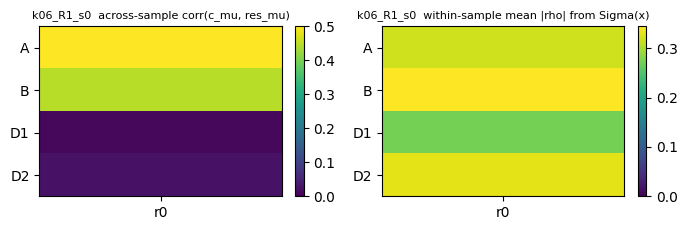

In [18]:
n = len(LOADED)
if n:
    fig, axes = plt.subplots(n, 2, figsize=(7, 2.4 * n), squeeze=False)
    for r, (label, L) in enumerate(LOADED.items()):
        d = L["test"]
        for c, (M, title) in enumerate([(L["corr_mu"], "across-sample corr(c_mu, res_mu)"),
                                        (L["sigma_abs"], "within-sample mean |rho| from Sigma(x)")]):
            ax = axes[r, c]
            vmax = 0.5 if c == 0 else max(0.05, np.nanmax(M))
            im = ax.imshow(M if c else np.abs(M), cmap="viridis", vmin=0, vmax=vmax, aspect="auto")
            ax.set_yticks(range(d["C"])); ax.set_yticklabels(CONCEPTS[:d["C"]])
            ax.set_xticks(range(d["R"])); ax.set_xticklabels([f"r{j}" for j in range(d["R"])])
            ax.set_title(f"{label[:26]}  {title}", fontsize=8)
            plt.colorbar(im, ax=ax, fraction=0.05)
    plt.tight_layout(); plt.show()

### 3.7 Dose-response across runs

With runs at several kappa, the parent correlation should rise linearly with kappa/2 while
the null concepts stay flat. This is the figure that turns the ratio into a measurement.

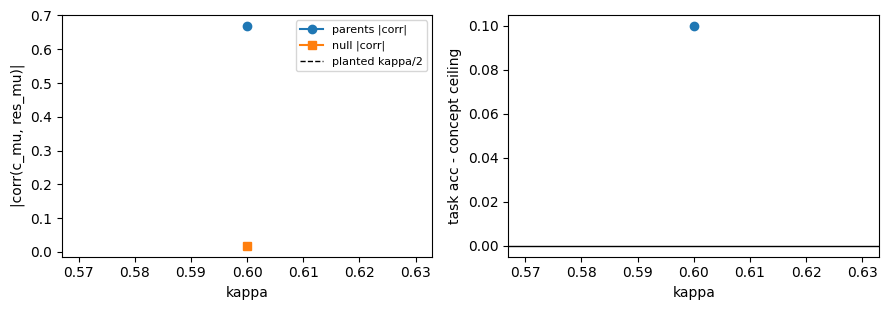

In [19]:
if LOADED:
    ks = np.array([L["kappa"] for L in LOADED.values()])
    order = np.argsort(ks)
    labels = np.array(list(LOADED.keys()))[order]
    par = [np.abs(LOADED[l]["corr_mu"])[parents_of(LOADED[l]["cfg"]["data"]["experiment"])[0]].mean() for l in labels]
    nul = [np.abs(LOADED[l]["corr_mu"])[parents_of(LOADED[l]["cfg"]["data"]["experiment"])[1]].mean() for l in labels]
    acc = [LOADED[l]["acc"] - LOADED[l]["ceiling"] for l in labels]
    fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
    ax[0].plot(ks[order], par, "o-", label="parents |corr|"); ax[0].plot(ks[order], nul, "s-", label="null |corr|")
    ax[0].plot(ks[order], ks[order] / 2, "k--", lw=1, label="planted kappa/2")
    ax[0].set_xlabel("kappa"); ax[0].set_ylabel("|corr(c_mu, res_mu)|"); ax[0].legend(fontsize=8)
    ax[1].plot(ks[order], acc, "o-"); ax[1].axhline(0, color="k", lw=1)
    ax[1].set_xlabel("kappa"); ax[1].set_ylabel("task acc - concept ceiling")
    plt.tight_layout(); plt.show()

### 3.8 Per-cell accuracy: where does the model get X from?

`y = 4A + 2B + X`, so the predicted X bit is `argmax(y_pred) % 2`. Splitting by the four
(A, B) cells separates the two ways of being right about X: reading it off the concepts (the
cells where P(X=1) is far from 0.5) and reading it off channel 5 through the residual (the
A ≠ B cells, where the concepts give a coin flip). A model that never touched the residual
matches the "best guess from concepts" column in every cell and sits at 0.5 on the A ≠ B
cells. The task accuracy per cell is lower than the X-bit accuracy by the concept errors.

In [20]:
for label, L in LOADED.items():
    d = L["test"]; A, B, X = d["c_true"][:, 0], d["c_true"][:, 1], d["X"]
    pred = d["y_pred"].argmax(1); pred_X = pred % 2
    print(f"\n{label}  (kappa={L['kappa']})")
    print(f"{'cell':<10} {'n':>5} {'P(X=1)':>7} {'concept guess':>13} {'y acc':>7} {'X-bit acc':>10}")
    for a in (0, 1):
        for b in (0, 1):
            mk = (A == a) & (B == b); p1 = X[mk].mean()
            print(f"A={a} B={b}   {mk.sum():>5} {p1:>7.3f} {max(p1, 1 - p1):>13.3f} "
                  f"{(pred[mk] == d['y_true'][mk]).mean():>7.3f} {(pred_X[mk] == X[mk]).mean():>10.3f}")
    coin = A != B
    print(f"X-bit accuracy on the A != B cells: {(pred_X[coin] == X[coin]).mean():.3f}   (0.5 = residual unused)")


k06_R1_s0  (kappa=0.6)
cell           n  P(X=1) concept guess   y acc  X-bit acc
A=0 B=0    2500   0.197         0.803   0.913      0.924
A=0 B=1    2500   0.495         0.505   0.485      0.502
A=1 B=0    2500   0.496         0.504   0.859      0.874
A=1 B=1    2500   0.801         0.801   0.771      0.794
X-bit accuracy on the A != B cells: 0.688   (0.5 = residual unused)


### 3.9 What the residual bit agrees with

The residual's thresholded probability is a bit. Its agreement rate with X, with each
concept and with each concept's complement says in one line whether it is carrying the
hidden variable or a *copy of an observed concept*. The complement is included because the
head can absorb either sign. Also reported: how saturated the residual probability is, and
the partial correlation of `res_mu` with X once the concepts are regressed out, which is
the number that survives for a residual that carries X and goes to zero for a copy.

The second table repeats the agreement with X inside each (A, B) cell, sign-free. A linear
head indexes its classes by (A, B, X) jointly, so a residual that equals X in some cells and
1 − X in others is exactly as useful to it as one that equals X everywhere. Pooled agreement
near 0.5 with high per-cell agreement and mixed signs therefore means "X re-coded by the
concepts", which is a different object from X for the covariance readout.

In [21]:
print(f"{'run':<28} {'r=X':>6} {'r=A':>6} {'r=1-A':>6} {'r=B':>6} {'r=1-B':>6} {'r=D1':>6} {'r=D2':>6} | {'saturated':>9} {'pcorr(r,X|c)':>13}")
for label, L in LOADED.items():
    d = L["test"]; C = d["C"]
    for j in range(d["R"]):
        pr = d["probs"][:, C + j]; bit = pr > 0.5
        agree = lambda t: np.mean(bit == (t > 0.5))
        c = d["c_true"]
        sat = np.mean(np.abs(pr - 0.5) > 0.45)
        pc = np.corrcoef(ols_clean(d["res_mu"], d["c_mu"])[:, j], d["X"])[0, 1]
        print(f"{(label if j == 0 else ''):<28} {agree(d['X']):>6.3f} {agree(c[:,0]):>6.3f} {agree(1-c[:,0]):>6.3f} "
              f"{agree(c[:,1]):>6.3f} {agree(1-c[:,1]):>6.3f} {agree(c[:,2]):>6.3f} {agree(c[:,3]):>6.3f} | "
              f"{sat:>9.3f} {pc:>+13.3f}   res{j}")
print("\nAgreement near 0.5 everywhere = noise; near 1 on X = the residual carries X; near 1 on A or 1-A = a concept copy.")

# Per-cell agreement with X. A linear head indexes classes by (A, B, X) jointly, so it can
# decode a residual that equals X in some (A, B) cells and 1 - X in others just as well as
# one that equals X everywhere. Pooled agreement then sits near 0.5 while the residual is
# fully informative. max(agree, 1 - agree) inside each cell is the sign-free readout; if the
# four cells disagree on the sign, the residual is X re-coded by the concepts, not X.
print(f"\n{'run':<28} {'A0B0':>7} {'A0B1':>7} {'A1B0':>7} {'A1B1':>7}   per-cell |agreement(r, X)| and sign")
for label, L in LOADED.items():
    d = L["test"]; C = d["C"]; A, B, X = d["c_true"][:, 0], d["c_true"][:, 1], d["X"]
    for j in range(d["R"]):
        bit = d["probs"][:, C + j] > 0.5; cells = []
        for a in (0, 1):
            for b in (0, 1):
                mk = (A == a) & (B == b); ag = np.mean(bit[mk] == (X[mk] > 0.5))
                cells.append(f"{max(ag, 1-ag):.3f}{'+' if ag >= 0.5 else '-'}")
        print(f"{(label if j == 0 else ''):<28} " + " ".join(f"{s:>7}" for s in cells) + f"   res{j}")

run                             r=X    r=A  r=1-A    r=B  r=1-B   r=D1   r=D2 | saturated  pcorr(r,X|c)
k06_R1_s0                     0.489  0.740  0.260  0.307  0.693  0.506  0.496 |     0.678        -0.724   res0

Agreement near 0.5 everywhere = noise; near 1 on X = the residual carries X; near 1 on A or 1-A = a concept copy.

run                             A0B0    A0B1    A1B0    A1B1   per-cell |agreement(r, X)| and sign
k06_R1_s0                     0.937-  0.518-  0.589+  0.821+   res0


### 3.10 Head weights: what the head does with the residual

For a linear head, `head.0.weight` is `[8 classes × (A, B, D1, D2, r…)]`. Class k has bits
(A, B, X) = (k>>2, (k>>1)&1, k&1). A head that reads X from the residual has the residual
column positive on the odd classes (X = 1) and negative on the even ones, with the same
pattern in every (A, B) block. A head that uses the residual as a second vote on A has the
residual column following the A pattern instead: one sign on classes 0-3, the other on 4-7.

In [22]:
for label, L in LOADED.items():
    sd = torch.load(L["dir"] / "model_best.pth", map_location="cpu")
    keys = [k for k in sd if k.startswith("head.") and k.endswith("weight")]
    if len(keys) != 1:
        print(f"{label}: non-linear head ({len(keys)} weight matrices), skipping"); continue
    W = sd[keys[0]].float().numpy(); C = L["test"]["C"]; R = L["test"]["R"]
    names = CONCEPTS[:C] + [f"r{j}" for j in range(R)]
    print(f"\n{label}")
    print(f"{'class':<6} {'(A,B,X)':<9} " + " ".join(f"{n:>7}" for n in names))
    for k in range(W.shape[0]):
        bits = (k >> 2, (k >> 1) & 1, k & 1)
        print(f"{k:<6} {str(bits):<9} " + " ".join(f"{w:>+7.2f}" for w in W[k]))
    # Which pattern does each residual column follow? Correlate it with the class bit patterns.
    kk = np.arange(W.shape[0]); patt = {"A": kk >> 2, "B": (kk >> 1) & 1, "X": kk & 1}
    for j in range(R):
        col = W[:, C + j]
        print(f"  r{j} column follows: " + "  ".join(f"{n}={np.corrcoef(col, p)[0,1]:+.2f}" for n, p in patt.items()))


k06_R1_s0
class  (A,B,X)         A       B      D1      D2      r0
0      (0, 0, 0)   -2.77   -3.16   -0.10   +0.04   +2.64
1      (0, 0, 1)   -3.02   -2.74   +0.78   +1.01   -3.28
2      (0, 1, 0)   -2.85   +1.61   +0.07   +0.17   -2.94
3      (0, 1, 1)   -3.14   +1.61   +0.11   +0.25   -3.22
4      (1, 0, 0)   +2.37   -3.15   -0.03   +0.04   -1.24
5      (1, 0, 1)   +2.00   -3.17   -0.24   -0.19   +1.49
6      (1, 1, 0)   +1.49   +1.17   -0.40   -0.27   -2.02
7      (1, 1, 1)   +1.03   +2.02   -0.54   -0.45   +1.91
  r0 column follows: A=+0.38  B=-0.32  X=+0.03


### Worked example: the kappa 0.9 run of 8 September

`planted_planted_parents_planted_parents_kappa09_corr04_L_int_extension_loss_weight_1_2026-09-08_17-50-00_b226c`
(stacked encoder from scratch, global covariance, lr 1e-3, no weight decay, extended L_int at
weight 1, one residual) is the negative control that the cleaning step exists for. From the
sections above, on test:

- **3.2** y accuracy 0.627 against a concept-only ceiling of 0.732. Below the ceiling because
  each concept is read at only about 0.92, and all four together at 0.71.
- **3.8** On the A ≠ B cells the model's X bit is at 0.51 and 0.54: chance. It never read
  channel 5. In the A = B cells it matches the concept guess.
- **3.9** The residual bit equals 1 − A on 83 % of samples and X on 39 %, below chance. 89 %
  of residual probabilities are saturated. Partial correlation with X given the concepts: −0.01.
- **3.3** Raw probe on X 0.63, cleaned 0.51, ΔAUC over the concept-only probe 0.000.
- **3.4 / 3.5** Across-sample corr with A −0.93, with B +0.34, distractors near zero; the Σ(x)
  cross-block has A at 0.84 and the rest near 0.2; parent-to-null ratio 15.
- **3.10** The residual column of the head follows the A pattern, not the X pattern: the head
  uses the residual as a second vote on A.

Every identification statistic fires, and it is identifying a copied concept. The −0.22 raw
correlation with X is inherited entirely from A, since X is correlated with A by design.
With a learning rate of 1e-3, no weight decay, and concepts read at 0.92, routing A through
the free channel a second time was the fastest way to lower the target loss, and learning X
from a corrupted digit never won the race. The matched backbone (concepts at 0.99, so a second
vote on A is worthless), weight decay, no L_int, and kappa 0.6 are what changed in the
15 September run, whose train accuracy passed the ceiling at epoch 48.

The general rule this run gives: a large, well-structured concept-residual correlation is
not evidence of a hidden concept until the cleaned probe and the per-cell X-bit accuracy say
the residual carries something the concepts do not.

## What to conclude

In order; each step is only meaningful if the one before it passed.

1. **Backbone** (§2): channels 1-4 near 0.98, channel 5 well above 0.9. If channel 5 is
   poor, the corruption is too strong for the digit reader and the residual has nothing to
   work with.
2. **Settings** (§3.1): no precision penalty, no L_int, linear head, a learning covariance.
3. **Task accuracy above the ceiling** (§3.2): the only way to get there is the residual.
4. **The residual holds X** (§3.3, §3.8, §3.9): the cleaned probe clears the X ceiling, the X bit is
   above 0.5 on the A ≠ B cells, and the residual bit agrees with X rather than with a concept.
5. **The correlation points at the parents** (§3.4, §3.5): parent columns near kappa/2, null
   columns near the kappa = 0 floor. `planted_swap` must flip it.
6. **Σ(x)** (§3.4, within-sample) only once concept corruption is on; on clean concept
   channels the concept variances collapse and that panel is expected to be empty.

If 1-4 pass and 5 comes out flat, that is a real negative about the covariance as an
identification tool and worth reporting as one. If 3 fails, the residual was never trained
and 5 tells you nothing.